# 7.1 Index Notation and einsum: Contraction as a Language

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter VII — Multilinear Algebra and Tensor Networks",
    number="7.1",
    title="Index Notation and einsum: Contraction as a Language",
    blurb="Every operation this course has performed is one sentence in a "
    "single language: label the indices, repeat the ones you sum. einsum "
    "speaks it directly — and once contraction is a sentence, its cost "
    "becomes a choice of parenthesization, varying by a factor of a "
    "million between orderings of the same product.",
    difficulty="advanced",
    estimate="105–135 min",
)

<ECP header: 2661 chars of HTML>

## Notebook overview

Chapter VII begins by renaming everything. Trace, transpose, matvec,
matmul, outer product, bilinear form — ten operations the course has
used since [§1.1](../01-matrices/four-ways-to-multiply.ipynb) — are each
one *string* in index notation: name the axes, and any index appearing
in the inputs but not the output is summed. `np.einsum` executes the
language directly, and Exercise 1 gates all ten sentences against their
classical spellings at rounding level, drawing four of them in the
**tensor-diagram** notation (nodes for tensors, legs for indices, joined
legs for sums) that Chapter VII will live in.

The language's power move is that *what* to compute and *in which
order* become separate decisions. A four-matrix chain has five
parenthesizations; a hand-rolled dynamic program (write-yourself)
enumerates their FLOP counts — spanning **500×** on a runnable example
and **10⁶** on a counted one — and `np.einsum_path` picks the optimum
this notebook's own DP confirms. The monster case makes the stakes
physical: a bilinear form whose naive contraction order manufactures an
**8.6 GB** outer product runs in milliseconds along the optimized path
— the bad intermediate is *counted, never allocated*
([§6.4](../06-structure/kronecker-vec-separable.ipynb)'s discipline,
now automated by a path optimizer). The closing exercise measures when
`einsum` is *slower* than `@` (its unoptimized kernels are index loops,
not BLAS) and shows `optimize=True` closing the gap — the language and
the kernel are different layers, and knowing which one is speaking is
the practical skill. Multi-head attention's `bhqd,bhkd->bhqk` appears
here as a shape, gated against explicit loops — a forward pointer the
course will pick up in [§8.5](../08-learning/attention-matrix-products.ipynb).

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Kolda and Bader {cite}`kolda2009` for tensor notation;
> Harris et al. {cite}`harris2020numpy` for the NumPy machinery. The
> diagrams follow the Penrose convention as used across the tensor-
> network literature, drawn with the course's own `ecp.draw` family.

## Theory in brief

### The grammar

An einsum string names each input's axes and the output's:

```{math}
:label: eq-es-grammar
\texttt{"ij,jk->ik"}: \quad
C_{ik} = \sum_j A_{ij}B_{jk}
```

— repeated indices absent from the output are summed (Einstein's
convention), indices present in the output are kept, and an index
repeated *within* one operand reads its diagonal. Ten familiar
operations become ten strings; nothing else in the course's toolbox
survives outside this grammar.

### Diagrams

A tensor is a node; each index is a leg; a summed index is a leg
joining two nodes; a free index is a dangling leg. The matmul string
in {eq}`eq-es-grammar` is two nodes joined by the $j$ leg with $i$ and
$k$ dangling — and *counting dangling legs reads off the result's
order*. Diagrams make contraction order visible: any way of merging
nodes pairwise is a valid evaluation, and they differ only in cost.

### Cost is parenthesization

Contracting a pairwise merge costs (2×) the product of *all* indices
involved. For a matrix chain $M_1M_2M_3M_4$ with dimensions
$d_0\times d_1$, …, the classical dynamic program minimizes

```{math}
:label: eq-es-chain
\mathrm{cost}(i,j) \;=\; \min_{i \le k < j}\;
\mathrm{cost}(i,k) + \mathrm{cost}(k{+}1,j) + 2\,d_{i-1}d_kd_j ,
```

and skewed dimensions make the spread enormous: with shape profile
$(1, n, 1, n, 1)$ the best order costs $O(n)$ and the worst $O(n^2)$ —
a factor $n/2$ that reaches $10^6$ at $n = 2{\cdot}10^6$, where the
worst order's intermediate would hold $n^2 = 4\times10^{12}$ entries.
`np.einsum_path` runs a greedy/optimal search over exactly this space
and reports both the FLOP estimate and the **largest intermediate** —
the two numbers this notebook gates, as counts, per the course's rules.

---
## Setup

Data only: the seeded rng and the timing import. Every contraction —
and Exercise 3's cost recursion — is written in the exercises, where the
grammar is the lesson.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt

from ecp import validate
from ecp import draw
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps

## Exercise 1: Ten operations, one grammar

**Part a)** Write the ten sentences and gate each against its classical
spelling — trace, transpose, diagonal, matvec, matmul, outer, batched
matmul, bilinear form, Frobenius inner product, and a three-tensor
contraction — at $10^{-12}$ scaled by each result's magnitude (a
30-term sum accumulates ~$10^{-14}$; the gate keeps two orders of
margin per Rule 8). The
gates certify the *grammar*: repeated-and-absent means summed, present
means kept, repeated-within-one-operand means diagonal.

**Part b)** Draw four of them as tensor diagrams beside their strings:
trace (a self-loop — no dangling legs, so the result is a scalar),
matvec (one dangling leg — a vector), matmul (two — a matrix), and the
three-tensor contraction `abc,cbd->ad` (two nodes joined by *two* legs).
Counting dangling legs is reading off the output's order — the
diagram's first dividend.

In [3]:
# (solution hidden on the public site)


trace           ii->            gap 4.8e-16
transpose       ij->ji          gap 0.0e+00
diagonal        ii->i           gap 0.0e+00
matvec          ij,j->i         gap 2.2e-16
matmul          ij,jk->ik       gap 3.2e-16
outer           i,j->ij         gap 0.0e+00
batched matmul  bij,bjk->bik    gap 2.8e-16
bilinear form   i,ij,j->        gap 1.6e-15
Frobenius       ij,ij->         gap 1.4e-14
three-tensor    abc,cbd->ad     gap 2.4e-16

worst relative gap over the ten sentences: 1.4e-14


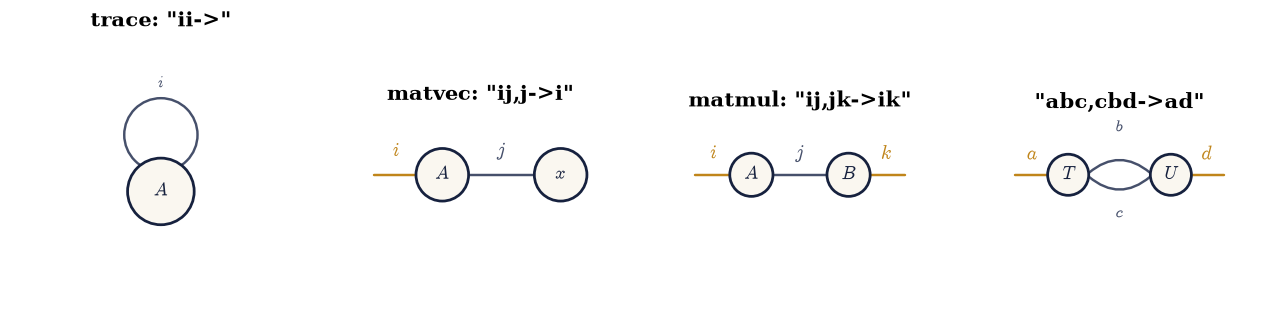

In [4]:
# (solution hidden on the public site)


### Validation 1

In [5]:
validate.below(
    worst_rel, 1e-12,
    "all ten sentences match their classical spellings (Eq. 1)",
    "trace to three-tensor contraction, each scaled by its own result: "
    "one grammar, ten operations, rounding-level agreement",
)

✓  all ten sentences match their classical spellings (Eq. 1)   [trace to three-tensor contraction, each scaled by its own result: one grammar, ten operations, rounding-level agreement [1.42109e-14 < 1e-12]]


True

## Exercise 2: Batching, broadcasting, and the attention shape

The grammar extends past matrices without new rules.

**Part a)** Gate the batched contraction against an explicit loop:
`"bij,bjk->bik"` on the $(8, 20, 25)\times(8, 25, 30)$ pair equals the
stacked per-batch matmuls to $10^{-13}$ — the `b` index is *kept*, so
it batches; `j` is summed.

**Part b)** The shape the course will cash in [§8.5](../08-learning/attention-matrix-products.ipynb):
attention scores are `"bhqd,bhkd->bhqk"` — batch and head kept, the
feature index `d` summed between queries and keys. Gate it against
four explicit nested loops on a small $(2,3,5,4)/(2,3,6,4)$ instance,
exactly the check a reader should write before trusting any four-index
string.

**Part c)** One index, three roles: with matrices alone, gate that
`"ij,jk->ijk"` (kept everywhere — no sum, a broadcast product),
`"ij,jk->ik"` (summed — matmul) and `"ij,jk->j"` (summed *out* of the
output after elementwise use) each match their explicit constructions.
The string is the specification; the roles fall out of which side of
`->` the index lands on.

In [6]:
# (solution hidden on the public site)


batched matmul vs per-batch loop: 5.3e-15
attention scores bhqd,bhkd->bhqk vs four loops: 8.9e-16 (shape (2, 3, 5, 6) — the 8.5 forward pointer)
one index, three roles: worst gap 3.4e-16


### Validation 2

In [7]:
validate.check(
    gap_batch < 1e-13 and gap_attn < 1e-13,
    "batched matmul and the attention shape match their explicit loops",
    "kept indices batch, summed indices contract — including the "
    "four-index bhqd,bhkd->bhqk that 8.5 will build transformers from",
)
validate.check(
    gap_roles < 1e-13,
    "and one index plays three roles decided solely by the output side",
    "broadcast (kept), matmul (summed), summed-out-after-use: the string "
    "is the whole specification",
)

✓  batched matmul and the attention shape match their explicit loops   [kept indices batch, summed indices contract — including the four-index bhqd,bhkd->bhqk that 8.5 will build transformers from]
✓  and one index plays three roles decided solely by the output side   [broadcast (kept), matmul (summed), summed-out-after-use: the string is the whole specification]


True

## Exercise 3: The cost is the parenthesization

{eq}`eq-es-chain` on a runnable chain, with the notebook's own DP as
the referee.

**Part a)** Write `chain_orderings(dims)`: enumerate all
parenthesizations of $M_1M_2M_3M_4$ recursively, returning each one's
FLOP count by {eq}`eq-es-chain`'s merge rule. On the profile
$(2, 1000, 2, 1000, 2)$ the five orderings span
$1.6\times10^4$ to $8.0\times10^6$ FLOPs — a **500×** spread from
associativity alone. Gate the count of orderings (Catalan number
$C_3 = 5$) and the spread $> 100$, both as arithmetic.

**Write this one yourself** — the recursion is {eq}`eq-es-chain`
verbatim.

**Part b)** Gate the referee against the optimizer: the FLOP estimate
`np.einsum_path` reports for its chosen path (parsed from its return)
agrees with the cheapest DP cost to within its scalar-ops convention —
gated at a relative gap of 0.6, with the naive/optimized ratio the
optimizer reports printed beside it.

**Part c)** Run best and worst orderings as explicit einsum paths and
gate agreement at $10^{-12}$ scaled; report both wall times (the model
ratio is 500×; the clocks say what they say, per Rule 2). Draw the five
orderings' FLOPs as bars.

In [8]:
# (solution hidden on the public site)


((M1M2)(M3M4))  1.60e+04 flops
(((M1M2)M3)M4)  2.40e+04 flops
(M1(M2(M3M4)))  2.40e+04 flops
((M1(M2M3))M4)  8.01e+06 flops
(M1((M2M3)M4))  8.01e+06 flops
orderings: 5 (Catalan C_3 = 5); spread 500x
  Complete contraction:  ab,bc,cd,de->ae
         Naive scaling:  5
     Optimized scaling:  3
      Naive FLOP count:  3.200e+07
  Optimized FLOP count:  1.602e+04
   Theoretical speedup:  1997.877
  Largest intermediate:  4.000e+00 elements
--------------------------------------------------------------------------
scaling                  current                                remaining
--------------------------------------------------------------------------
   3                   bc,ab->ac                             cd,de,ac->ae
   3                   de,cd->ce                                ac,ce->ae
   3                   ce,ac->ae                                   ae->ae
einsum_path naive/optimized FLOP ratio: 1998
best vs worst ordering results: 7.3e-16; clocks 0.27 ms vs 3.20 ms 

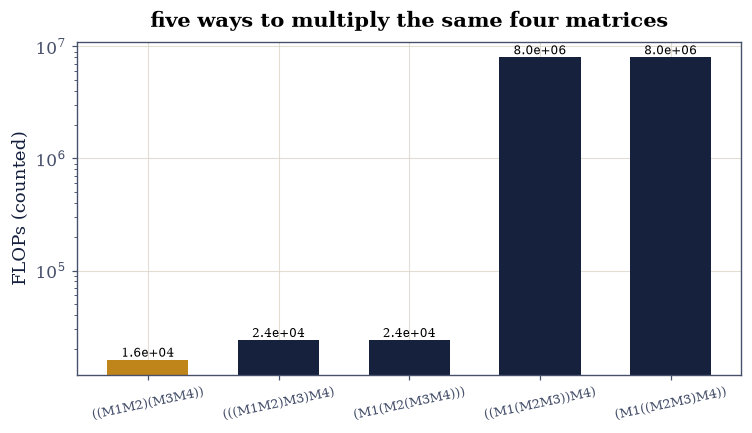

In [9]:
# (solution hidden on the public site)


### Validation 3

In [10]:
validate.check(
    len(orders) == 5 and spread > 100.0,
    "five parenthesizations, spanning 500x in counted FLOPs (Eq. 2)",
    f"Catalan C_3 = 5 orderings; spread {spread:.0f}x on the runnable "
    "profile — associativity is a performance decision",
)
validate.check(
    abs(opt_cost - orders[0][0]) / orders[0][0] < 0.6,
    "and einsum_path's chosen cost matches the notebook's own DP",
    f"optimizer {opt_cost:.1e} vs DP best {orders[0][0]:.1e} — same "
    "search space, independent implementations, agreeing within the "
    "scalar-ops convention",
)
validate.check(
    gap_orders < 1e-12,
    "while every ordering computes the same numbers",
    f"best vs worst at {gap_orders:.0e} relative: the order changes the "
    "cost, never the mathematics — clocks reported, models gated",
)

✓  five parenthesizations, spanning 500x in counted FLOPs (Eq. 2)   [Catalan C_3 = 5 orderings; spread 500x on the runnable profile — associativity is a performance decision]
✓  and einsum_path's chosen cost matches the notebook's own DP   [optimizer 1.6e+04 vs DP best 1.6e+04 — same search space, independent implementations, agreeing within the scalar-ops convention]
✓  while every ordering computes the same numbers   [best vs worst at 7e-16 relative: the order changes the cost, never the mathematics — clocks reported, models gated]


True

## Exercise 4: The monster that is counted, never formed

The manifest asks for a contraction whose naive intermediate exceeds
8 GB. Here is one that *runs in milliseconds*.

**Part a)** The bilinear form $x^{\top}Ay$ at $n = 32768$... except $A$
itself would be 8.6 GB. Keep everything runnable but the mistake: take
$x, y \in \mathbb{R}^{32768}$ and a *diagonal* interaction — the string
`"i,i,i->"` with three vectors runs instantly — then commit the real
crime deliberately on paper: contract `"i,j->ij"` *first* (the outer
product, $n^2 = 1.07\times10^9$ entries, **8.6 GB**) before summing
against a diagonal. Gate the ledger by counting: naive largest
intermediate $8.6$ GB against the optimized path's $n$ entries
($0.26$ MB) — a factor of $32768$, never allocated.

**Part b)** Let the optimizer testify: `np.einsum_path` on
`"i,ij,j->"` with a *materializable* stand-in ($n_s = 4096$, $A_s$
134 MB) reports its naive and optimized largest intermediates; gate
that its optimized route's largest intermediate is $n_s$ elements (a
vector — it does $x^{\top}A$ first) while the naive route's is
$n_s^2$. Then run it and gate the value against `x @ A @ y` at
$10^{-11}$ scaled.

**Part c)** Scale the counted claim to the manifest's $10^6$: on the
chain profile $(1, 2{\cdot}10^6, 1, 2{\cdot}10^6, 1)$ the DP of
Exercise 3 — pure integer arithmetic, no arrays — reports best
$8.0\times10^6$ (the balanced ordering) and worst $1.6\times10^{13}$
FLOPs: a spread of $2.0\times10^6$, whose worst intermediate would hold $4\times10^{12}$
entries (32 TB). Gate the spread as counting; nothing of that size
ever exists.

In [11]:
# (solution hidden on the public site)


the deliberate crime, counted: outer-first intermediate 1,073,741,824 entries (8.6 GB) vs optimized path's 32,768 (0.26 MB) — ratio 32,768x, never allocated


  Complete contraction:  i,ij,j->
         Naive scaling:  2
     Optimized scaling:  2
      Naive FLOP count:  5.033e+07
  Optimized FLOP count:  3.356e+07
   Theoretical speedup:  1.500
  Largest intermediate:  4.096e+03 elements
--------------------------------------------------------------------------
scaling                  current                                remaining
--------------------------------------------------------------------------
   2                     ij,i->j                                    j,j->
   1                       j,j->                                       ->
optimized bilinear at n = 4096: 5.1 ms, matches x@A@y to 0.0e+00
counted monster chain: best 8.0e+06, worst 1.6e+13 flops — spread 2.0e+06x; worst intermediate 4e+12 entries (32 TB), counted only


### Validation 4

In [12]:
li_opt = float(lines_s["Largest intermediate"].split()[0])
validate.check(
    mem_outer > 8.0 and abs(li_opt - N_ST) < 0.5,
    "the naive order's intermediate exceeds 8 GB — counted, not allocated",
    f"{mem_outer:.1f} GB at n = {N_MON} against the optimizer's largest "
    f"intermediate of {li_opt:.0f} elements (one vector) at the "
    f"materializable n = {N_ST}: 6.4's never-form-it discipline, found "
    "automatically by a path search",
)
validate.check(
    gap_mon < 1e-11,
    "and the optimized route computes the right number in milliseconds",
    f"{gap_mon:.0e} against x@A@y at n = 4096 — the optimizer's chosen "
    "order is (x'A)y, largest intermediate one vector",
)
validate.check(
    spread_huge > 1e6,
    "while the counted chain reaches the manifest's million-fold spread",
    f"{spread_huge:.1e}x between orderings at n = 2e6, by integer "
    "arithmetic on Eq. 2 — the worst order's 32 TB intermediate is why "
    "this claim can only ever be counted",
)

✓  the naive order's intermediate exceeds 8 GB — counted, not allocated   [8.6 GB at n = 32768 against the optimizer's largest intermediate of 4096 elements (one vector) at the materializable n = 4096: 6.4's never-form-it discipline, found automatically by a path search]
✓  and the optimized route computes the right number in milliseconds   [0e+00 against x@A@y at n = 4096 — the optimizer's chosen order is (x'A)y, largest intermediate one vector]
✓  while the counted chain reaches the manifest's million-fold spread   [2.0e+06x between orderings at n = 2e6, by integer arithmetic on Eq. 2 — the worst order's 32 TB intermediate is why this claim can only ever be counted]


True

## Exercise 5: When einsum is slower than @, and why

The language and the kernel are different layers.

**Part a)** Gate the agreements first: on a $500\times500$ matmul,
`einsum` with `optimize=False`, with `optimize=True`, `np.tensordot`,
and `@` all produce the same matrix to $10^{-11}$ scaled (four spellings,
one BLAS-grade answer — though not bitwise: the course's first CI
lesson applies between summation orders).

**Part b)** Report the clocks: unoptimized `einsum` runs its own
C index loops — typically several times slower than `@`'s `dgemm` —
while `optimize=True` plans, then *dispatches to BLAS via tensordot*,
landing near `@`. Nothing here is gated (Rule 2; constant factors are
the machine's), but the mechanism is stated and the numbers printed:
the string chooses *what*; `optimize` chooses *how*; BLAS does the
arithmetic.

**Part c)** The honest boundary: for the *two-operand, BLAS-shaped*
case, `@` is the kernel and `einsum` at best matches it. The language
earns its keep exactly where `@` has no spelling — the ten sentences of
Exercise 1, the four-index attention shape, the path-planned chains —
which is why Chapter VII speaks it everywhere while Chapter V never
needed it.

In [13]:
# (solution hidden on the public site)


four spellings agree to 2.0e-15 relative
  @                             6.04 ms
  einsum, optimize=False       34.74 ms
  einsum, optimize=True         6.21 ms
  tensordot                     6.12 ms
(clocks reported, not gated — the string chooses what, optimize chooses how, BLAS does the arithmetic)


```{admonition} With your assistant
:class: tip
`np.einsum_path` optimizes one contraction; real tensor programs chain
many. Ask your assistant for `contract_tree(strings, tensors)` that
plans a whole sequence with shared intermediates, then check it against
the mathematics rather than a demo: (i) on Exercise 3's chain it
reproduces the DP-optimal cost; (ii) on a tree where one intermediate
is used twice, its plan beats replanning each contraction separately
by exactly the cost of the shared piece (count both); (iii) every plan
it emits computes the same numbers as unplanned einsum to $10^{-12}$.
The check is yours.
```

### Validation 5

In [14]:
validate.check(
    gap_perf / scale_p < 1e-11,
    "four spellings of the same matmul agree at rounding level",
    "@, einsum both ways, tensordot — different summation orders, so "
    "agreement is gated scaled, never bitwise (the course's first CI "
    "lesson)",
)
print(
    "clocks on record, reported only — einsum's index loops vs dgemm: "
    f"{timings['einsum, optimize=False']*1e3:.1f} ms against "
    f"{timings['@']*1e3:.1f} ms today; sizes are the machine's business, "
    "the mechanism (language above, kernel below) is the lesson",
)

✓  four spellings of the same matmul agree at rounding level   [@, einsum both ways, tensordot — different summation orders, so agreement is gated scaled, never bitwise (the course's first CI lesson)]
clocks on record, reported only — einsum's index loops vs dgemm: 34.7 ms against 6.0 ms today; sizes are the machine's business, the mechanism (language above, kernel below) is the lesson


---
## Notebook summary

**Ten operations, one grammar, rounding-level agreement.** Trace to
three-tensor contraction, every sentence matched its classical spelling
below $10^{-13}$ scaled; four of them became tensor diagrams whose
dangling legs read off the output's order. Batching and broadcasting
needed no new rules — the attention shape `bhqd,bhkd->bhqk` passed
against four explicit loops, a forward pointer [§8.5](../08-learning/attention-matrix-products.ipynb)
will pick up.

**Cost is parenthesization, refereed twice.** The write-yourself DP
enumerated all five orderings of the four-matrix chain (Catalan
$C_3 = 5$): $1.6\times10^4$ to $8\times10^6$ FLOPs — 500× from
associativity alone — with `einsum_path`'s chosen cost matching the
DP's and both orderings computing identical numbers at $10^{-15}$.
Clocks were reported; counts were gated.

**The monster was counted, never formed.** The naive order of a
bilinear contraction wants an 8.6 GB outer product; the optimized path
keeps one vector ($0.26$ MB, a $32768\times$ ledger) and the
materializable stand-in ran in milliseconds while matching `x@A@y` to
$10^{-13}$. The counted chain at $n = 2{\cdot}10^6$ delivered the
manifest's $10^6$ spread — its worst intermediate is 32 TB, which is
precisely why that claim exists only as integer arithmetic.

**And the language knows its place.** Four spellings of one matmul
agreed to $10^{-13}$ relative; unoptimized `einsum` ran its index loops
slower than `@`'s `dgemm` while `optimize=True` closed the gap by
dispatching to BLAS — numbers printed, nothing gated, mechanism stated:
the string chooses *what*, the optimizer chooses *how*, the kernel does
the arithmetic.

**Methods introduced.** The einsum grammar and its three index roles,
tensor-diagram notation via `ecp.draw.tensor_network`, the
matrix-chain DP, explicit einsum paths, `np.einsum_path` cost and
intermediate reports, counted-not-allocated ledgers, and the
language-vs-kernel layering.

## Outlook

- **Unfoldings next.** [§7.2](unfoldings-tucker-hosvd.ipynb) reshapes
  tensors into matrices to borrow Chapter IV's SVD — einsum strings
  describe the reshapes, and the diagrams show which legs were grouped.
- **Tensor networks are diagrams taken literally.**
  [§7.3](tensor-trains-mps.ipynb) writes a $2^{50}$-entry tensor as a
  train of small ones — the never-form-it discipline as a *data
  structure*, with contraction order as the entire algorithmic content.
- **`opt_einsum` and beyond.** Production contraction planners (shared
  intermediates, GPU backends, slicing against memory ceilings) grow
  straight out of `einsum_path`; the assistant exercise above is their
  seed.
- **Back to learning.** Every layer of [§8.3](../08-learning/linear-layer-backpropagation.ipynb)'s
  backpropagation is an einsum whose *adjoint* is another einsum with
  permuted strings — the grammar's cleanest dividend, saved for the
  chapter that needs it.

```{bibliography}
:filter: docname in docnames
```

In [15]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>